In [1]:
# Imports 

import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import datetime as dt 
import astropy 
import pytz 
import pandas as pd 
import astroplan 


c:\Users\johnm\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [47]:
# Define functions 

def get_observer(lat=41.66, lon=-91.53, height=0, timezone_str="US/Central"):
    location = astropy.coordinates.EarthLocation(
        lat=lat*astropy.units.deg,
        lon=lon*astropy.units.deg,
        height=height*astropy.units.m)
    return astroplan.Observer(location=location, timezone=timezone_str)





# Helper func 
def time_plottable_to_astroplan(time_plottable): 
    return astropy.time.Time(time_plottable.tz_convert('UTC').to_pydatetime())





# Calculate visiblity for a target 
def calc_visibility(Observer, Target, min_alt=25): 

    results = [] 
    timezone_str = str(Observer.timezone) 
    dates = pd.date_range(
        start='2025-12-31 12:00:00',
        end='2026-12-31 12:00:00',
        freq='3D', # 3D = Calculate visibility every 3rd day, 10D = every 10th day, etc 
        tz=timezone_str
    )

    for date_plottable in dates: 

        # Date of observation 
        date_astroplan = time_plottable_to_astroplan(date_plottable)

        # Target rise/set times (astroplan)
        target_rise_time_astroplan = Observer.target_rise_time(date_astroplan, Target, which='next', horizon=min_alt*astropy.units.deg)
        target_set_time_astroplan = Observer.target_set_time(date_astroplan, Target, which='next', horizon=min_alt*astropy.units.deg)

        # sunset -> evening civil -> evening nautical -> evening astronomical -> morning astronomical -> morning nautical -> morning civil -> sunrise 
        sunset1_astroplan = Observer.sun_set_time(date_astroplan, which='next')
        sunset2_astroplan = Observer.twilight_evening_civil(date_astroplan, which='next')
        sunset3_astroplan = Observer.twilight_evening_nautical(date_astroplan, which='next')
        sunset4_astroplan = Observer.twilight_evening_astronomical(date_astroplan, which='next')
        sunrise4_astroplan = Observer.twilight_morning_astronomical(date_astroplan, which='next')
        sunrise3_astroplan = Observer.twilight_morning_nautical(date_astroplan, which='next')
        sunrise2_astroplan = Observer.twilight_morning_civil(date_astroplan, which='next')
        sunrise1_astroplan = Observer.sun_rise_time(date_astroplan, which='next')
        
        # Express all times as time since noon today 
        target_rise_relative = target_rise_time_astroplan - date_astroplan 
        target_set_relative = target_set_time_astroplan - date_astroplan 

        sunset1_relative = sunset1_astroplan - date_astroplan 
        sunset2_relative = sunset2_astroplan - date_astroplan 
        sunset3_relative = sunset3_astroplan - date_astroplan 
        sunset4_relative = sunset4_astroplan - date_astroplan 
        sunrise4_relative = sunrise4_astroplan - date_astroplan 
        sunrise3_relative = sunrise3_astroplan - date_astroplan 
        sunrise2_relative = sunrise2_astroplan - date_astroplan 
        sunrise1_relative = sunrise1_astroplan - date_astroplan 
        
        # Choose which sunrise/sunset time to use when checking if it's night 
        sun_set_time_astroplan = sunset1_astroplan 
        sun_rise_time_astroplan = sunrise1_astroplan 
        sun_set_relative = sun_set_time_astroplan - date_astroplan 
        sun_rise_relative = sun_rise_time_astroplan - date_astroplan 

        # Calculate when the target starts and stops being visible 

        # Currently visible 
        if target_set_time_astroplan<target_rise_time_astroplan: 

            # Sets before sunset 
            if target_set_time_astroplan<sun_set_time_astroplan: 

                if target_rise_time_astroplan<sun_set_time_astroplan: 
                    start=sun_set_time_astroplan 
                    end=sun_rise_time_astroplan 
                if sun_set_time_astroplan<target_rise_time_astroplan<sun_rise_time_astroplan: 
                    start=target_rise_time_astroplan 
                    end=sun_rise_time_astroplan 
                if target_rise_time_astroplan>sun_rise_time_astroplan: 
                    start=sun_rise_time_astroplan 
                    end=sun_rise_time_astroplan 
                
            # Sets during the night 
            if sun_set_time_astroplan<target_set_time_astroplan<sun_rise_time_astroplan: 
                start=sun_set_time_astroplan 
                end=target_set_time_astroplan 
            
            # Sets after sunrise 
            if target_set_time_astroplan>sun_rise_time_astroplan: 
                start=sun_set_time_astroplan 
                end=sun_rise_time_astroplan 

        # Currently not visible 
        if target_set_time_astroplan>target_rise_time_astroplan: 

            # Rises before sunset 
            if target_rise_time_astroplan<sun_set_time_astroplan: 

                if target_set_time_astroplan<sun_set_time_astroplan: 
                    start=sun_set_time_astroplan 
                    end=sun_set_time_astroplan 
                if sun_set_time_astroplan<target_set_time_astroplan<sun_rise_time_astroplan: 
                    start=sun_set_time_astroplan 
                    end=target_set_time_astroplan 
                if target_set_time_astroplan>sun_rise_time_astroplan: 
                    start=sun_set_time_astroplan 
                    end=sun_rise_time_astroplan 

            # Rises during the night 
            if sun_set_time_astroplan<target_rise_time_astroplan<sun_rise_time_astroplan: 

                if target_set_time_astroplan<sun_rise_time_astroplan: 
                    start=target_rise_time_astroplan 
                    end=target_set_time_astroplan 
                if target_set_time_astroplan>sun_rise_time_astroplan: 
                    start=target_rise_time_astroplan
                    end=sun_rise_time_astroplan
            
            # Rises after sunrise 
            if target_rise_time_astroplan>sun_rise_time_astroplan: 
                start = sun_rise_time_astroplan  
                end = sun_rise_time_astroplan 

        try: 
            start_relative = start - date_astroplan 
            end_relative = end - date_astroplan 
        except: 
            # If target is always up, use sunrise and sunset as start/end times 
            if Target.dec >= 0: 
                start_relative = sun_set_relative 
                end_relative = sun_rise_relative 
            # If target is never up, use sunrise as both to show its never up? 
            if Target.dec < 0: 
                start_relative = sun_rise_relative 
                end_relative = sun_rise_relative 

        # Save results as a dictionary 
        results.append({
            "target_rise_relative": target_rise_relative, 
            "target_set_relative": target_set_relative, 

            "sun_rise_relative": sun_rise_relative, 
            "sun_set_relative": sun_set_relative, 

            "sunset1_relative": sunset1_relative, 
            "sunset2_relative": sunset2_relative, 
            "sunset3_relative": sunset3_relative, 
            "sunset4_relative": sunset4_relative, 
            "sunrise4_relative": sunrise4_relative,  
            "sunrise3_relative": sunrise3_relative, 
            "sunrise2_relative": sunrise2_relative, 
            "sunrise1_relative": sunrise1_relative, 

            "start_relative": start_relative, 
            "end_relative": end_relative, 
        })

    return dates, results 





# Create plot 
def plot_visibility(Observer, Target, min_alt, dates, results): 

    timezone_str = str(Observer.timezone)
    fig, ax = plt.subplots(figsize=(12,8)) 

    # xaxis 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b')) 
    ax.set_xlabel("Date of observation") 
    ax.set_xlim(dates[0], dates[-1]) 
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
    
    # yaxis 
    ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=pytz.timezone(timezone_str))) 
    ax.set_ylabel(f"Local time ({timezone_str})") 
    ax.set_ylim(dates[0], dates[0]+pd.Timedelta(days=1))
    ax.yaxis.set_major_locator(mdates.HourLocator(interval=2)) 
    ax.yaxis.set_minor_locator(mdates.HourLocator(interval=1)) 
    
    # Title 
    target_coord_str = Target.coord.to_string('hmsdms', precision=1) 
    target_coord_str = target_coord_str.replace("h", ":")
    target_coord_str = target_coord_str.replace("m", ":", 1)
    target_coord_str = target_coord_str.replace("s", "", 1)
    target_coord_str = target_coord_str.replace("d", "°")
    target_coord_str = target_coord_str.replace("m", "\'")
    target_coord_str = target_coord_str.replace("s", "\"")

    lat = Observer.location.lat.deg
    lon = Observer.location.lon.deg
    lat_str = f"{abs(lat):.2f}° {'N' if lat >= 0 else 'S'}"
    lon_str = f"{abs(lon):.2f}° {'E' if lon >= 0 else 'W'}"
    observer_coord_str = f"{lat_str}, {lon_str}"    
    ax.set_title(f"Observer Lat/Lon: {observer_coord_str} \nTarget RA/Dec: {target_coord_str}")

    # "It just works" -Todd Howard 
    def get_time(string): 
        return [pd.Timestamp((x[string] + time_plottable_to_astroplan(dates[0])).to_datetime()).tz_localize("UTC").tz_convert(timezone_str) for x in results]

    # Target rise/set time 
    # If target never rises or never sets, skip this step 
    try: 
        ax.scatter(dates, get_time("target_set_relative"), color="tab:red", s=10, label=f"Target set (alt < {min_alt}°)", zorder=2)
        ax.scatter(dates, get_time("target_rise_relative"), color="tab:green", s=10, label=f"Target rise (alt > {min_alt}°)", zorder=2)
    except: 
        pass 

    # Highlight period that target is observable 
    ax.fill_between(dates, get_time("start_relative"), get_time("end_relative"), color="black", alpha=0.5, zorder=1, label=f"Target visibile (alt > {min_alt}° and night)") 

    # Sun rise/set times (cutoff for when "night" begins)
    ax.plot(dates, get_time("sun_set_relative"), color="cornflowerblue", label="Beginning of night", zorder=2)
    ax.plot(dates, get_time("sun_rise_relative"), color="gold", label="End of night", zorder=2)

    # Day vs night background colors (show shades of twilight) 
    ax.fill_between(dates, dates[0], get_time("sunset1_relative"), color="gold", alpha=0.2, zorder=0, label="Day")
    ax.fill_between(dates, get_time("sunset1_relative"), get_time("sunset2_relative"), color="cornflowerblue", alpha=0.1, zorder=0, label="Civil twilight")
    ax.fill_between(dates, get_time("sunset2_relative"), get_time("sunset3_relative"), color="cornflowerblue", alpha=0.2, zorder=0, label="Nautical twilight")
    ax.fill_between(dates, get_time("sunset3_relative"), get_time("sunset4_relative"), color="cornflowerblue", alpha=0.4, zorder=0, label="Astronomical twilight")
    ax.fill_between(dates, get_time("sunset4_relative"), get_time("sunrise4_relative"), color="cornflowerblue", alpha=0.6, zorder=0, label="Night")
    ax.fill_between(dates, get_time("sunrise4_relative"), get_time("sunrise3_relative"), color="cornflowerblue", alpha=0.4, zorder=0)
    ax.fill_between(dates, get_time("sunrise3_relative"), get_time("sunrise2_relative"), color="cornflowerblue", alpha=0.2, zorder=0)
    ax.fill_between(dates, get_time("sunrise2_relative"), get_time("sunrise1_relative"), color="cornflowerblue", alpha=0.1, zorder=0)
    ax.fill_between(dates, get_time("sunrise1_relative"), dates[0]+pd.Timedelta(days=1), color="gold", alpha=0.2, zorder=0)

    # Legend and gridlines 
    ax.legend(loc="upper right") 
    ax.grid(alpha=0.6, which="major")
    ax.grid(alpha=0.3, which="minor")





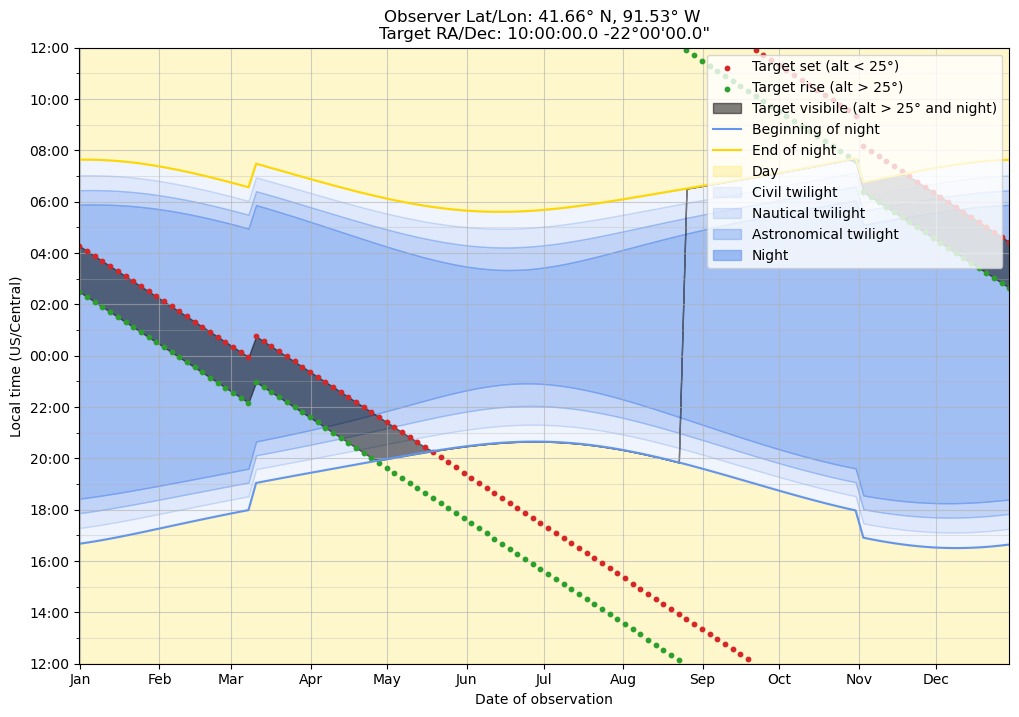

In [ ]:
# Run code 

# Test code on various ra/dec positions 
cassiopeia = '23 30 00 +60 00 00'
gemini = "7 00 00 +20 00 00"
ursa_minor = "0 00 00 +80 00 00" 
aquarius = "21 00 00 -10 00 00"
antlia = "10 00 00 -30 00 00"
hydra = "10 00 00 -22 00 00"



# Choose input parameters 
target_radec_str = hydra                        # Location of target (RA/dec string)
min_alt = 25                                    # Minimum altitude that target must reach above horizon (degrees) 
(observer_lat, observer_lon) = (41.66, -91.53)  # Location of telescope (latitude/longitude). Default: Iowa City, change to your latitude/longitude 



# Calculate visiblity 
Observer = get_observer(lat=observer_lat, lon=observer_lon) 
Target = astroplan.FixedTarget(coord=astropy.coordinates.SkyCoord(target_radec_str, unit=(astropy.units.hourangle, astropy.units.deg)) ) 
dates, results = calc_visibility(Observer, Target, min_alt) 

# Plot visibility 
plot_visibility(Observer, Target, min_alt, dates, results)




41d39m36s


In [26]:
Target.coord.dec

<Latitude 20. deg>